## Data Reading

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
df = pd.read_csv("project_data.csv")
df.head()

C:\Users\ksjad\AppData\Local\Temp\ipykernel_21388\640791801.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("project_data.csv")


,_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID
0,1,019-0001-13.pdf,R.J.'s Tree Farms,"International Brotherhood Of Teamsters, Local 879",2010-05-01,2013-04-30,Private,"Labour Relations Act, 1995",0 - 50,30620,Agriculture and Natural Resources,Crop Production,Ontario - Province wide,NaN,NaN
1,2,021-0004-02.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2000-01-01,2002-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,NaN,NaN
2,3,021-0004-05.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2002-09-01,2005-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,NaN,NaN
3,4,021-0004-09.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2005-09-01,2009-09-30,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,NaN,NaN
4,5,031-0001-05.pdf,Abitibi-Price Inc,Iwa Canada (Industrial Wood And Allied Workers...,2001-09-01,2005-08-31,Private,"Labour Relations Act, 1995",51 - 100,30239,Agriculture and Natural Resources,Forestry and Logging,"THUNDER BAY, C",NaN,NaN


## Data Exploration

In [ ]:
df.count()

70616

In [ ]:
df.printSchema()

root
 |-- _id: long (nullable = true)
 |-- Name: string (nullable = true)
 |-- Employer: string (nullable = true)
 |-- Union: string (nullable = true)
 |-- Agreement Start Date: date (nullable = true)
 |-- Agreement Expiry Date: date (nullable = true)
 |-- Industrial Sector Type: string (nullable = true)
 |-- Labour Legislation (Act): string (nullable = true)
 |-- Number of Employees: string (nullable = true)
 |-- Legacy Relationship ID: string (nullable = true)
 |-- Industry: string (nullable = true)
 |-- Sector: string (nullable = true)
 |-- Agreement Location: string (nullable = true)
 |-- OLRB Construction Industry Areas: string (nullable = true)
 |-- Relationship ID: string (nullable = true)



In [ ]:
#df.shape 
print((df.count(),len(df.columns)))

(70616, 15)


In [ ]:
df.describe().display()

summary,_id,Name,Employer,Union,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID
count,70616,70616,70607,70607,70607,70603,70607,70339,70607,70611,65024,2516,3172
mean,35308.5,null,null,null,null,null,184.15265169612996,30310.686864835534,null,null,null,9.4688995215311,29950.43442622951
stddev,20385.227641603615,null,null,null,null,null,690.3826773667057,23978.495691560034,null,null,null,6.877498794862354,18155.720553471347
min,1,019-0001-13.pdf,Ottawa Hospital,"""United Steel Workers"" United Steel, Paper and Forestry, Rubber, Manufacturing, Energy, Allied Industrial on Behalf of Local 49M, (London)",Federal,Ambulance Services Collective Bargaining Act,0,100,Abrasive Product Manufacturing,-,ABERFOYLE,1,10062
max,70616,998.pdf,Équipe de santé familiale Communautaire de l'est d'Ottawa,le Syndicat des employés de la fonction publique de l'Ontario et sa section locale 666,Provincial,Toronto Transit Commission Labour Disputes Resolution Act,997,d,Zoos and Botanical Gardens,Wood Product Manufacturing,"ZURICH, VL",9;8;29;30;12;18;11;10,R-9998


In [ ]:
df.columns

['_id',
 'Name',
 'Employer',
 'Union',
 'Agreement Start Date',
 'Agreement Expiry Date',
 'Industrial Sector Type',
 'Labour Legislation (Act)',
 'Number of Employees',
 'Legacy Relationship ID',
 'Industry',
 'Sector',
 'Agreement Location',
 'OLRB Construction Industry Areas',
 'Relationship ID']

In [ ]:
#df.isnull().sum()

from pyspark.sql.functions import col, when, count, sum

df.select([sum(when(col(c).isNull(),1).otherwise(0)).alias(c) for c in df.columns]).display()


_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID
0,0,9,9,10,11,9,13,9,277,9,5,5592,68100,67444


In [ ]:
for col in df.columns:
    print(f'Number of distinct values in column {col}:',df.select(col).distinct().count())

Number of distinct values in column _id: 70616
Number of distinct values in column Name: 70615
Number of distinct values in column Employer: 20777
Number of distinct values in column Union: 9443
Number of distinct values in column Agreement Start Date: 6892
Number of distinct values in column Agreement Expiry Date: 6210
Number of distinct values in column Industrial Sector Type: 5
Number of distinct values in column Labour Legislation (Act): 22
Number of distinct values in column Number of Employees: 596
Number of distinct values in column Legacy Relationship ID: 24158
Number of distinct values in column Industry: 358
Number of distinct values in column Sector: 128
Number of distinct values in column Agreement Location: 3882
Number of distinct values in column OLRB Construction Industry Areas: 132
Number of distinct values in column Relationship ID: 2999


# Data Cleaning

### Romoving extra space from Employer column

In [ ]:
from pyspark.sql.functions import trim,col

df = df.withColumn(
    "Employer",
    trim(col("Employer"))
)


## Drop null values from Employeer column

In [ ]:
df = df.dropna(subset=['Employer'])

In [ ]:
df.count()

70607

In [ ]:
df.select([sum(when(col(c).isNull(),1).otherwise(0)).alias(c) for c in df.columns]).display()

_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID
0,0,0,0,1,2,0,4,0,268,0,0,5583,68091,67435


## Adding formatted column `employee_count` for number of employees 

In [ ]:
from pyspark.sql.functions import col, when, instr, regexp_replace, split

df = df.withColumn(
    "employees_clean",
    regexp_replace(col("Number of Employees"), " ", "")
)

df = df.withColumn(
    "employee_count",
    when(
        col("employees_clean").rlike("^[0-9]+-[0-9]+$"),
        (split(col("employees_clean"), "-")[0].cast("int") +
         split(col("employees_clean"), "-")[1].cast("int")) / 2
    )
    .when(
        col("employees_clean").rlike("^[0-9]+\\+$"),
        regexp_replace(col("employees_clean"), "\\+", "").cast("int") + 50
    )
    .otherwise(col("employees_clean").cast("int"))
)

df = df.drop("employees_clean")


In [ ]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "employee_bucket",
    when(col("employee_count") < 51, "0–50")
    .when(col("employee_count") < 101, "51–100")
    .when(col("employee_count") < 251, "101–250")
    .when(col("employee_count") < 501, "251–500")
    .otherwise("500+")
)


In [ ]:
df.limit(5).display()

_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID,employee_count,employee_bucket
1,019-0001-13.pdf,R.J.'s Tree Farms,"International Brotherhood Of Teamsters, Local 879",2010-05-01,2013-04-30,Private,"Labour Relations Act, 1995",0 - 50,30620,Agriculture and Natural Resources,Crop Production,Ontario - Province wide,null,null,25.0,0–50
2,021-0004-02.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2000-01-01,2002-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50
3,021-0004-05.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2002-09-01,2005-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50
4,021-0004-09.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2005-09-01,2009-09-30,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50
5,031-0001-05.pdf,Abitibi-Price Inc,"Iwa Canada (Industrial Wood And Allied Workers Of Canada), Local 2693",2001-09-01,2005-08-31,Private,"Labour Relations Act, 1995",51 - 100,30239,Agriculture and Natural Resources,Forestry and Logging,"THUNDER BAY, C",null,null,75.5,51–100


# Feature Engineering

### Contract length

In [ ]:
from pyspark.sql.functions import col, to_date, datediff

df = df.withColumn(
    "contract_length_days",
    datediff(col("Agreement Expiry Date"), col("Agreement Start Date"))
)


df.limit(5).display()

_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID,employee_count,employee_bucket,contract_length_days
1,019-0001-13.pdf,R.J.'s Tree Farms,"International Brotherhood Of Teamsters, Local 879",2010-05-01,2013-04-30,Private,"Labour Relations Act, 1995",0 - 50,30620,Agriculture and Natural Resources,Crop Production,Ontario - Province wide,null,null,25.0,0–50,1095
2,021-0004-02.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2000-01-01,2002-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,973
3,021-0004-05.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2002-09-01,2005-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,1095
4,021-0004-09.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2005-09-01,2009-09-30,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,1490
5,031-0001-05.pdf,Abitibi-Price Inc,"Iwa Canada (Industrial Wood And Allied Workers Of Canada), Local 2693",2001-09-01,2005-08-31,Private,"Labour Relations Act, 1995",51 - 100,30239,Agriculture and Natural Resources,Forestry and Logging,"THUNDER BAY, C",null,null,75.5,51–100,1460


In [ ]:
from pyspark.sql.functions import col, to_date, datediff, ceil

df = df.withColumn(
    "contract_length_months",
    ceil(col('contract_length_days')/30)
)

df.limit(5).display()

_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID,employee_count,employee_bucket,contract_length_days,contract_length_months
1,019-0001-13.pdf,R.J.'s Tree Farms,"International Brotherhood Of Teamsters, Local 879",2010-05-01,2013-04-30,Private,"Labour Relations Act, 1995",0 - 50,30620,Agriculture and Natural Resources,Crop Production,Ontario - Province wide,null,null,25.0,0–50,1095,37
2,021-0004-02.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2000-01-01,2002-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,973,33
3,021-0004-05.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2002-09-01,2005-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,1095,37
4,021-0004-09.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2005-09-01,2009-09-30,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,1490,50
5,031-0001-05.pdf,Abitibi-Price Inc,"Iwa Canada (Industrial Wood And Allied Workers Of Canada), Local 2693",2001-09-01,2005-08-31,Private,"Labour Relations Act, 1995",51 - 100,30239,Agriculture and Natural Resources,Forestry and Logging,"THUNDER BAY, C",null,null,75.5,51–100,1460,49


### Start_year of aggrement

In [ ]:
from pyspark.sql.functions import year

df = df.withColumn('start_year',year(col('Agreement Start Date')))
df.limit(5).display()

_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID,employee_count,employee_bucket,contract_length_days,contract_length_months,start_year
1,019-0001-13.pdf,R.J.'s Tree Farms,"International Brotherhood Of Teamsters, Local 879",2010-05-01,2013-04-30,Private,"Labour Relations Act, 1995",0 - 50,30620,Agriculture and Natural Resources,Crop Production,Ontario - Province wide,null,null,25.0,0–50,1095,37,2010
2,021-0004-02.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2000-01-01,2002-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,973,33,2000
3,021-0004-05.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2002-09-01,2005-08-31,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,1095,37,2002
4,021-0004-09.pdf,Beef Improvement Ontario,Ontario Public Service Employees Union,2005-09-01,2009-09-30,Private,"Labour Relations Act, 1995",0 - 50,33862,Agriculture and Natural Resources,Support Activities for Agriculture and Forestry,Ontario - Province wide,null,null,25.0,0–50,1490,50,2005
5,031-0001-05.pdf,Abitibi-Price Inc,"Iwa Canada (Industrial Wood And Allied Workers Of Canada), Local 2693",2001-09-01,2005-08-31,Private,"Labour Relations Act, 1995",51 - 100,30239,Agriculture and Natural Resources,Forestry and Logging,"THUNDER BAY, C",null,null,75.5,51–100,1460,49,2001


## Data Visualization

Text(0.5, 1.0, 'Histogram of contract duration')

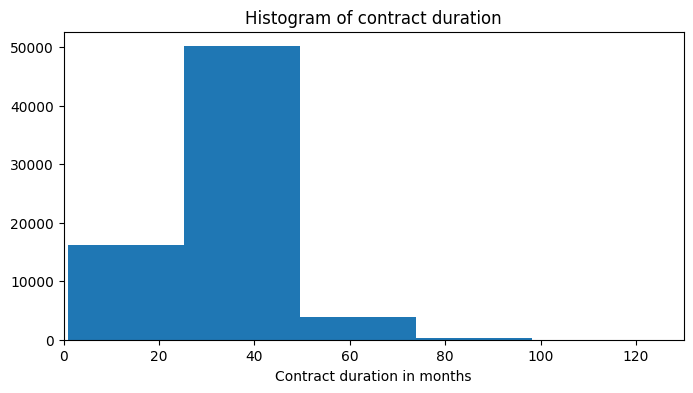

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df.select('contract_length_months').toPandas())
plt.xlim(0,130)
plt.xlabel('Contract duration in months')
plt.title('Histogram of contract duration')

#### Insights:

* Around 50,000 Agreements have 25-45 months of contracts.

* And 15000+ agreements are 0-25 months of contracts in length.

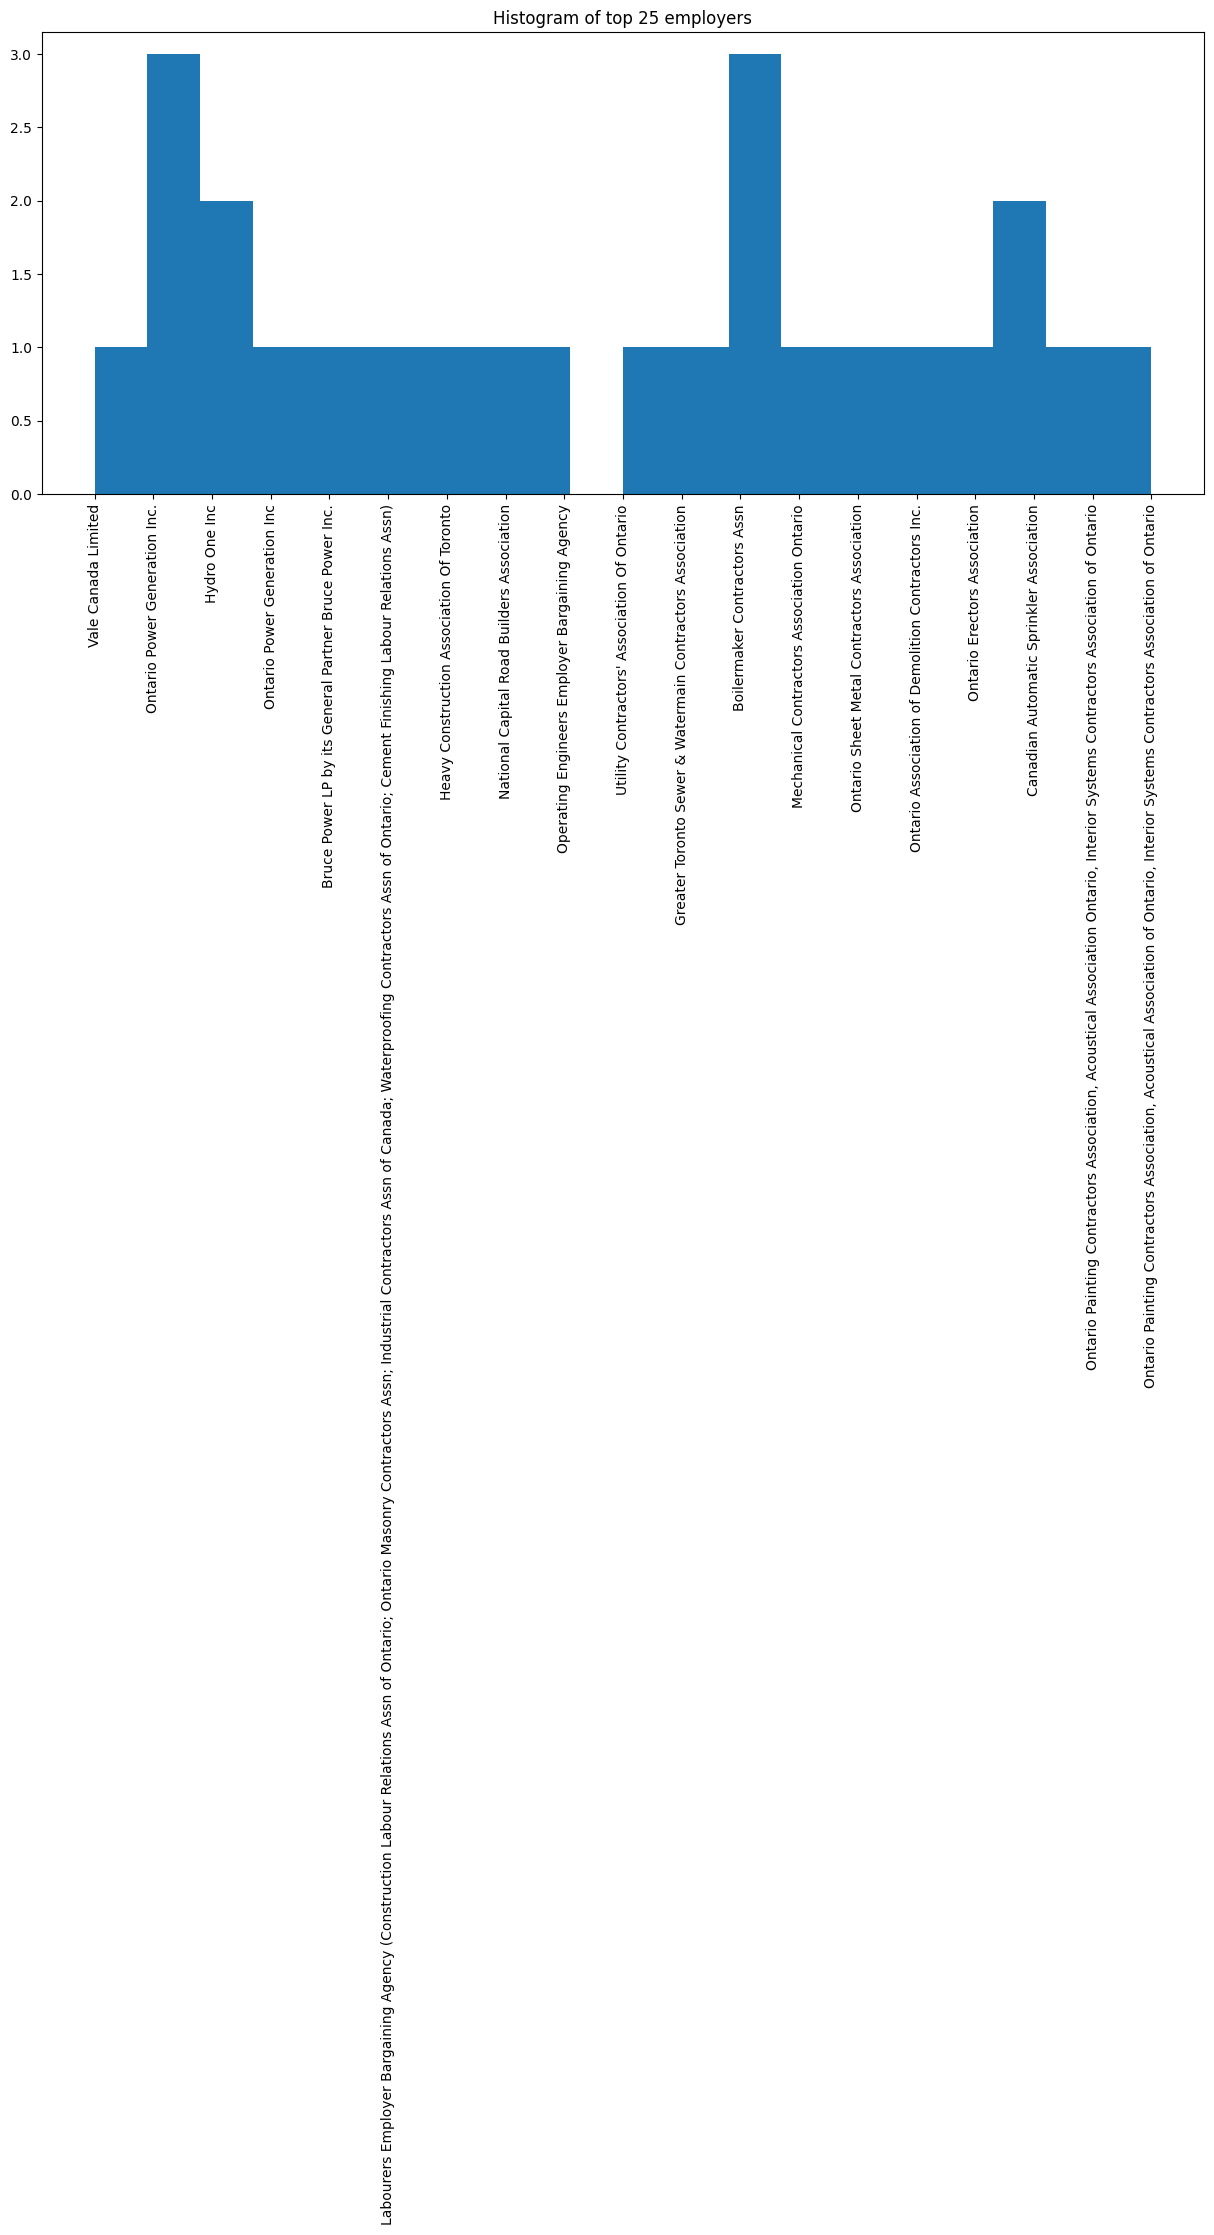

In [ ]:

from pyspark.sql.functions import col

plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
pdf = df.filter(col('employee_count')>1000).select(col('Employer')).dropna().limit(25).toPandas()
plt.hist(pdf['Employer'], bins=20)
plt.title('Histogram of top 25 employers')
plt.show()


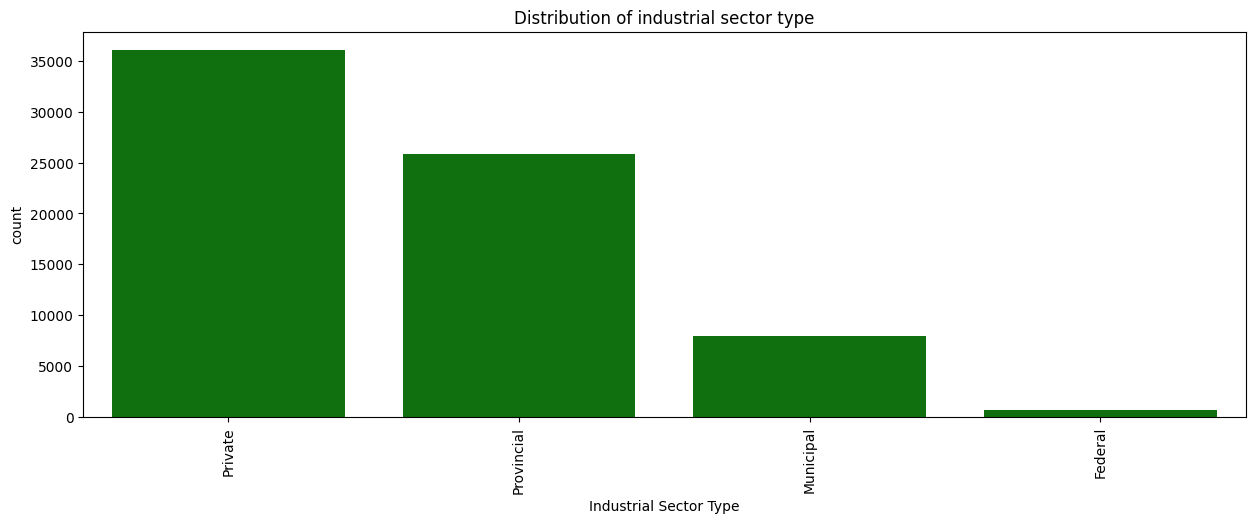

In [ ]:
plt.figure(figsize=(15, 5))
plt.xticks(rotation=90)
pdf = df.toPandas()
sns.countplot(x=pdf['Industrial Sector Type'], color='Green')
plt.title('Distribution of industrial sector type')
plt.show()

#### Insights:

* The Private sector has the highest number of agreements, indicates that collective bargaining is most prevalent in private organizations

* Provincial agreements are significantly fewer than private, but still substantial, reflects centralized bargaining in education, healthcare, and public services

* Municipal agreements are relatively limited, suggesting localized and standardized bargaining structures.

* Federal-level collective agreements are rare compared to other sectors.

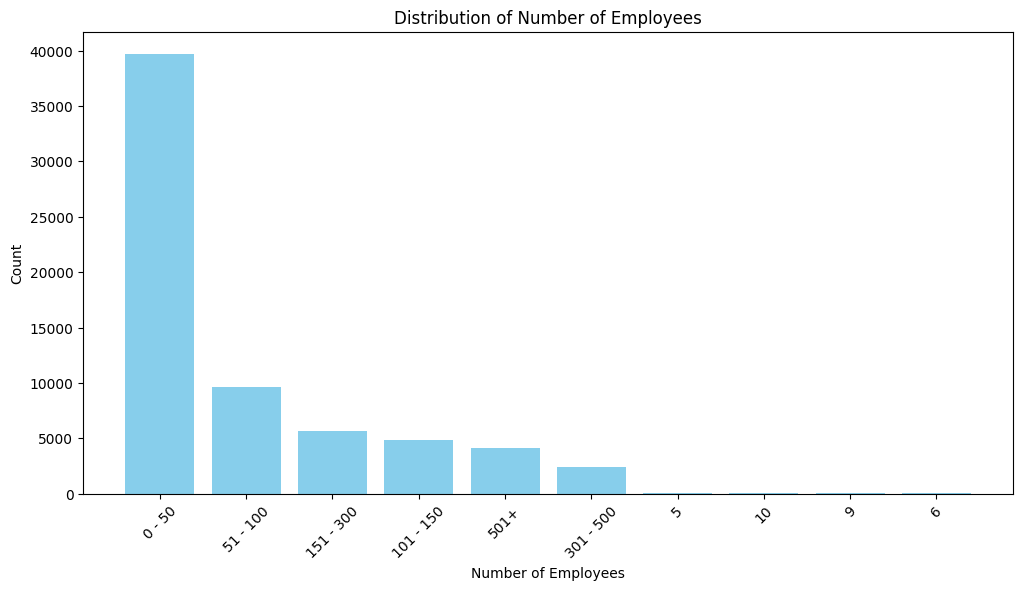

In [ ]:
import matplotlib.pyplot as plt

 
pdf = df.dropna(subset=[ 'Number of Employees']).groupBy('Number of Employees').count().orderBy('count', ascending=False).limit(10).toPandas()


plt.figure(figsize=(12,6))
plt.bar(pdf['Number of Employees'], pdf['count'],color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.title('Distribution of Number of Employees')
plt.show()


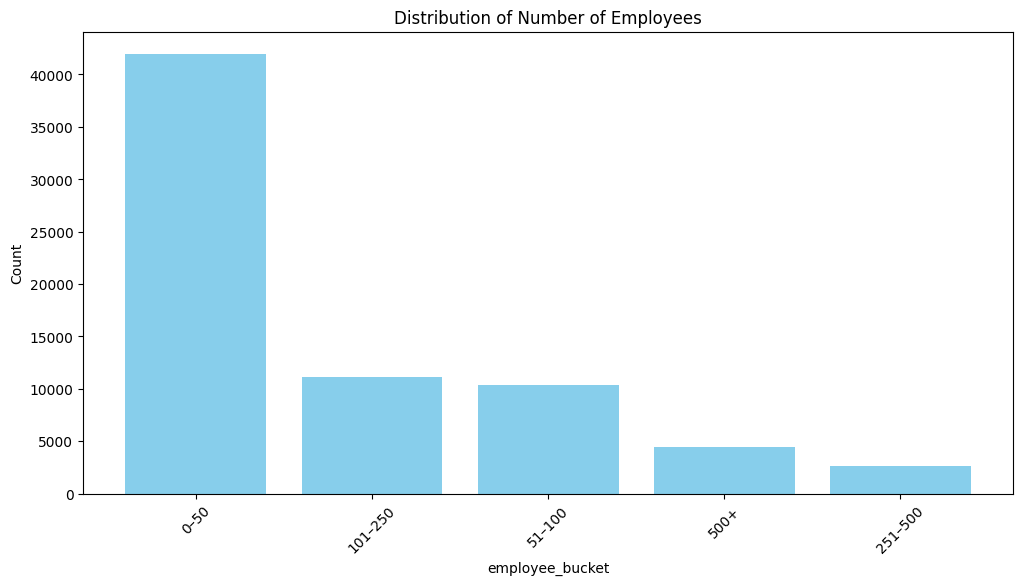

In [ ]:

 
pdf = df.dropna(subset=[ 'employee_bucket']).groupBy('employee_bucket').count().orderBy('count', ascending=False).toPandas()


plt.figure(figsize=(12,6))
plt.bar(pdf['employee_bucket'], pdf['count'],color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('employee_bucket')
plt.ylabel('Count')
plt.title('Distribution of Number of Employees')
plt.show()

### Interpretation

* Raw numeric values in `Number of Employyes`→ noisy, hard to interpret

* Bucketed values → clearer distribution pattern

* Most agreements involve small organizations (0–50 employees)

Text(0, 0.5, 'Count')

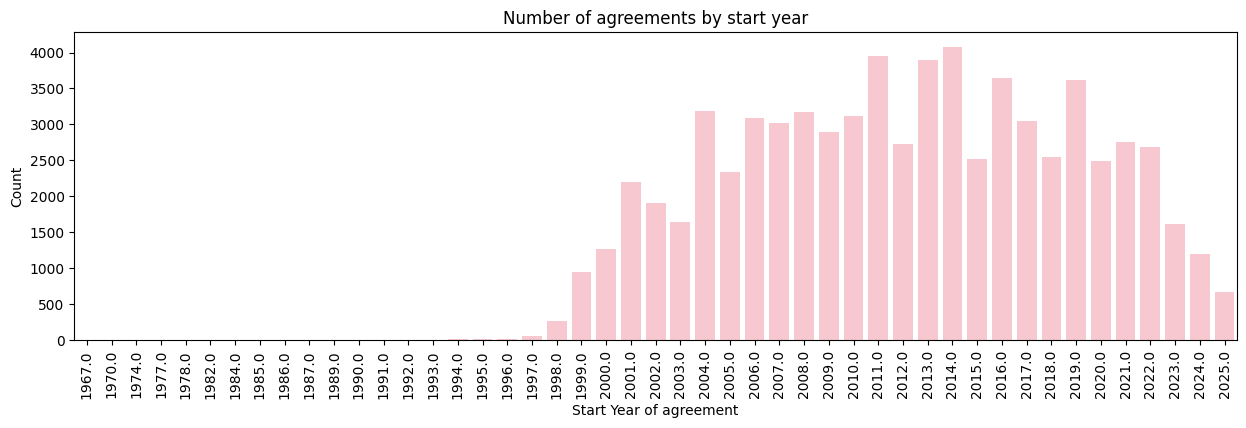

In [ ]:
plt.figure(figsize=(15,4))
sns.countplot(df.toPandas(), x='start_year', color='Pink')
plt.xticks(rotation=90)
plt.xlabel('Start Year of agreement')
plt.title('Number of agreements by start year')
plt.ylabel('Count')

Insights:

* Most of the agreements started between 2001 and 2022.

* Highest agreements started in 2014, around 4000.

## Data Analysis

### Contract Length more than 10 years

In [ ]:
df.filter(col("contract_length_days") > 3650).limit(10).display()

_id,Name,Employer,Union,Agreement Start Date,Agreement Expiry Date,Industrial Sector Type,Labour Legislation (Act),Number of Employees,Legacy Relationship ID,Industry,Sector,Agreement Location,OLRB Construction Industry Areas,Relationship ID,employee_count,employee_bucket,contract_length_days,contract_length_months,start_year
9882,251-0021-11.pdf,Elk Lake Planing Mill Ltd,Elk Lake Planning Mill Employees Association,2001-06-01,2011-05-31,Private,"Labour Relations Act, 1995",101 - 150,26511,Manufacturing,Wood Product Manufacturing,ELK LAKE,null,null,125.5,101–250,3651,122,2001
10326,271-0052-18.pdf,Thunder Bay Fine Papers Inc,"International Brotherhood Of Electrical Workers, Local 1565",2008-05-01,2018-04-30,Private,"Labour Relations Act, 1995",0 - 50,44937,Manufacturing,Paper Manufacturing,"THUNDER BAY, C",null,null,25.0,0–50,3651,122,2008
10886,289-0011-02.pdf,Southam Inc,"Communications Workers Of America, Local 102",1993-01-01,2002-12-31,Private,"Labour Relations Act, 1995",0 - 50,15938,"Transport, Communications, ? Utilities",Publishing Industries (except Internet),"OTTAWA, C",null,null,25.0,0–50,3651,122,1993
10958,289-0062-11.pdf,Osprey Media Group Inc (Sault Star),"Communications, Energy And Paperworkers Union Of Canada, Local 436",2001-03-01,2011-02-28,Private,"Labour Relations Act, 1995",0 - 50,39710,"Transport, Communications, ? Utilities",Publishing Industries (except Internet),"SAULT STE MARIE, C",null,null,25.0,0–50,3651,122,2001
11857,304-0070-10.pdf,Royce Metal Products Ltd,"Sheet Metal Workers' International Association, Local 30",2000-05-01,2010-04-30,Private,"Labour Relations Act, 1995",0 - 50,30290,Manufacturing,Fabricated Metal Product Manufacturing,"TORONTO, C",null,null,25.0,0–50,3651,122,2000
11858,304-0070-30.pdf,Royce Metal Products Ltd,"Sheet Metal Workers' International Association, Local 30",2010-05-01,2030-04-30,Private,"Labour Relations Act, 1995",0 - 50,30290,Manufacturing,Fabricated Metal Product Manufacturing,"TORONTO, C",null,null,25.0,0–50,7304,244,2010
12043,304-0223-12.pdf,Klinec Electric Services & Mfg Ltd/Axotec Intl Ltd,Klinec Electric Services And Manufacturing Limited Employees Association,1996-11-18,2012-12-31,Private,"Labour Relations Act, 1995",0 - 50,41091,Manufacturing,Fabricated Metal Product Manufacturing,"WINDSOR, C",null,null,25.0,0–50,5887,197,1996
13664,322-12024-27 (273-0047).pdf,"Cascades Containerboard Packaging, A division of Cascades Canada ULC.",Independent Paperworkers Of Canada And Its Local 595,2011-07-01,2027-06-30,Private,"Labour Relations Act, 1995",101 - 150,12024,Manufacturing,Paper Manufacturing,"ETOBICOKE, C",null,null,125.5,101–250,5843,195,2011
13810,322-9084-22 (273-0043).pdf,Norampac Belleville a division of Cascades Canada Inc.,"Independent Paperworkers Of Canada, Local 7",2013-01-01,2022-12-31,Private,"Labour Relations Act, 1995",51 - 100,9084,Manufacturing,Paper Manufacturing,"BELLEVILLE, C",null,null,75.5,51–100,3651,122,2013
19398,409-0037-20.pdf,Electrical Power Systems Construction Assn,United Brotherhood Of Carpenters And Joiners Of America,2010-05-01,2020-04-30,Private,"Labour Relations Act, 1995",501+,14280,Construction,Heavy and Civil Engineering Construction,Ontario - Province wide,null,null,551.0,500+,3652,122,2010


### Avarge of contract length in months ordered by start year of aggrements.

In [ ]:

df.groupBy('start_year').avg('contract_length_months').orderBy('start_year').limit(10).display()

start_year,avg(contract_length_months)
null,null
1967,36.0
1970,25.0
1974,25.0
1977,13.0
1978,23.0
1982,22.0
1984,23.0
1985,25.0
1986,25.0


In [ ]:
from pyspark.sql.functions import avg, col

avg_contract_df = df.groupBy(
                    "start_year",
                    "Employer",
                    ).agg(
                    avg("contract_length_months").alias("avg_contract_months")
                ).orderBy(
                    "start_year",
                )

print(avg_contract_df.limit(10).display())



start_year,Employer,avg_contract_months
null,Bradgate Arms,null
1967,Ball Brothers General Contractors,36.0
1970,Ball Brothers Limited,25.0
1974,K. Mulrooney Trucking Ltd.,25.0
1977,Frank Watts Sod & Seed Supply Co Ltd,13.0
1978,Canadian Independent Sod Ltd,23.0
1982,Sivi Construction Ltd,22.0
1984,Leslie L. Solty & Sons Ltd,23.0
1985,Sumner Press Ltd,25.0
1986,Serr-Can Paving 710579 Ontario Ltd,25.0


None


#### Lastest Contracts

In [ ]:

spark.createDataFrame(avg_contract_df.tail(10)).display()

start_year,Employer,avg_contract_months
2025,International Logistics Solutions Canada Inc.,37.0
2025,West Haldimand General Hospital,25.0
2025,Coast To Coast Display Services,25.0
2025,Independent Electricity System Operator,37.0
2025,Limen Restoration Corp. / Limen Masonry Corp.,37.0
2025,ION Facility Services Inc.,37.0
2025,Xterra Construction Inc.,37.0
2025,Lakeridge Health Corporation,25.0
2025,Hornepayne Community Hospital,25.0
2025,Corporation Of The City Of Windsor,49.0


### Top 20 contract lengths' by count

In [ ]:
df.groupBy('contract_length_months').count().orderBy('count', ascending=False).limit(20).display()

contract_length_months,count
37,37409
25,12324
49,8460
61,2902
13,2094
36,403
23,379
15,341
38,319
31,312


### Top 15 Unions by Employee Count

In [ ]:
df.groupBy('Union').avg('employee_count').orderBy('avg(employee_count)', ascending=False).limit(15).display()

Union,avg(employee_count)
Ontario Public Service Employees Union,9915.0
"United Food and Commercial Workers, Local 175/ 633",6850.0
"The Ontario Pipe Trades Council of the United Association of Journeymen and Apprentices of the Plumbing and Pipe Fitting Industry of the United States and Canada, Local 628/800/527/663/67/46/401/71",6775.5
"Power Workers' Union, Canadian Union Of Public Employees - C.L.C. Local 1000",5147.0
Professional Association of Residents of Ontario,5133.333333333333
"International Association Of Bridge, Structural, Ornamental and Reinforcing Ironworkers and Ironworkers District Council Of Ontario, Local 700, 721, 736, 759, 765, 786",3900.0
"Sheet Metal Workers' International Association, Local 235/269/30/397/47/473/504/537/562",3750.0
"Labourers' International Union of North America, and the Labourers' International Union of North America, Ontario Provincial District Council, on behalf of its affiliated Local Unions, 183, 493, 506, 527, 607, 625, 837, 1036, 1059 and 1089",3275.5
Workers United Canada Council on its own behalf and on behalf of its Local 152,3000.0
"International Union Of Painters And Allied Trades, and the Ontario Council of the International Union of Painters and Allied Trades, Local 114/1494/1590/1671/1783/1824/1904/200/205/557",2625.5


In [ ]:
df.groupBy('Employer').avg('employee_count').orderBy('avg(employee_count)', ascending=False).limit(15).display()

Employer,avg(employee_count)
Crown In Right Of Ontario Represented By Management Board Of Cabinet (Ontario Government),12561.0
Crown In Right Of Ontario Represented By Management Board Of Cabinet,8500.0
Ontario Erectors Association,6000.0
Ontario Teaching Hospitals,5200.0
Council Of Academic Hospitals Of Ontario (Ontario Teaching Hospitals),5200.0
"Ontario Painting Contractors Association, Acoustical Association Ontario, Interior Systems Contractors Association of Ontario",4700.0
"Ontario Painting Contractors Association, Acoustical Association of Ontario, Interior Systems Contractors Association of Ontario",4500.0
University Health Network (Western & General Hospitals),3288.0
Ontario Sheet Metal Contractors Association,3025.5
Labourers Employer Bargaining Agency (Construction Labour Relations Assn of Ontario; Ontario Masonry Contractors Assn; Industrial Contractors Assn of Canada; Waterproofing Contractors Assn of Ontario; Cement Finishing Labour Relations Assn),2367.3333333333335


### Top 10 Labour Legislation Acts 

In [ ]:
df.groupBy('Labour Legislation (Act)').count().orderBy('count', ascending=False).limit(10).display()

Labour Legislation (Act),count
"Labour Relations Act, 1995",49979
Hospital Labour Disputes Arbitration Act,16244
Canada Labour Code (Part I-Industrial Relations),1838
Police Services Act,934
"Fire Protection & Prevention Act, 1997",579
Ambulance Services Collective Bargaining Act,349
Public Service Labour Relations Act,236
Crown Employees Collective Bargaining Act,111
Public Service Staff Relations Act,82
Federal Public Sector Labour Relations Act,60


# Model

In [ ]:
# imports for the model building

from pyspark.sql.functions import col

from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline


In [ ]:
#feature selection for the model

model_df = df.select(
    col("employee_count"),
    col("contract_length_months"),
    col("Industrial Sector Type")
).dropna()


In [ ]:
#encoding the categorical variable

sector_indexer = StringIndexer(
    inputCol="Industrial Sector Type",
    outputCol="Industry_type_index",
    handleInvalid="skip"
)


In [ ]:
assembler = VectorAssembler(
    inputCols=[
        "employee_count",
        "contract_length_months",
        "Industry_type_index"
    ],
    outputCol="features_raw"
)


In [ ]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)


In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)



In [ ]:
scores = []

for k in range(2, 9):
    kmeans = KMeans(k=k, seed=42, featuresCol="features")
    pipeline = Pipeline(stages=[
        sector_indexer,
        assembler,
        scaler,
        kmeans
    ])
    model = pipeline.fit(model_df)
    preds = model.transform(model_df)
    score = evaluator.evaluate(preds)
    scores.append((k, score))


spark.createDataFrame(scores, ["k", "silhouette"]).display()


k,silhouette
2,0.43634387159345406
3,0.5401819039885805
4,0.5115245299486525
5,0.38325614617725884
6,0.548313136986909
7,0.6109343871198131
8,0.6359132851609158


* For k = 8 got 0.63 silhouette value which is highest.

In [ ]:
clustered_df = model.transform(model_df)

clustered_df.select(
    "employee_count",
    "contract_length_months",
    "Industrial Sector Type",
    "prediction"
).limit(10).display()


employee_count,contract_length_months,Industrial Sector Type,prediction
25.0,37,Private,1
25.0,33,Private,1
25.0,37,Private,1
25.0,50,Private,1
75.5,49,Private,1
75.5,49,Private,1
25.0,49,Private,1
25.0,61,Private,2
125.5,49,Private,1
75.5,52,Private,2


In [ ]:
clustered_df.groupBy("prediction").count().display()


prediction,count
1,29681
2,3544
5,6098
4,12360
0,12254
6,6617
3,50
7,1


In [ ]:
clustered_df.groupBy("prediction").avg(
    "employee_count",
    "contract_length_months"
).display()


prediction,avg(employee_count),avg(contract_length_months)
1,47.2844075334389,37.27984232337185
2,91.73687923250564,64.34593679458239
5,519.3506067563136,35.7094129222696
4,76.696642394822,22.300161812297734
0,75.64884935531255,39.33507426146564
6,93.88295299984887,41.81577754269306
3,4368.5,34.24
7,24571.0,37.0


In [ ]:
clustered_df.groupBy("prediction", "Industrial Sector Type").count().display()


prediction,Industrial Sector Type,count
1,Private,29681
2,Private,3056
5,Private,1797
4,Private,1536
0,Provincial,12254
4,Provincial,9247
5,Provincial,3940
6,Municipal,5953
5,Municipal,360
2,Provincial,425


In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pcaFeatures"
)

pca_model = pca.fit(clustered_df)
pca_df = pca_model.transform(clustered_df)


In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

get_pc1 = udf(lambda v: float(v[0]), DoubleType())
get_pc2 = udf(lambda v: float(v[1]), DoubleType())

pca_plot_df = (
    pca_df
    .withColumn("pc1", get_pc1(col("pcaFeatures")))
    .withColumn("pc2", get_pc2(col("pcaFeatures")))
)


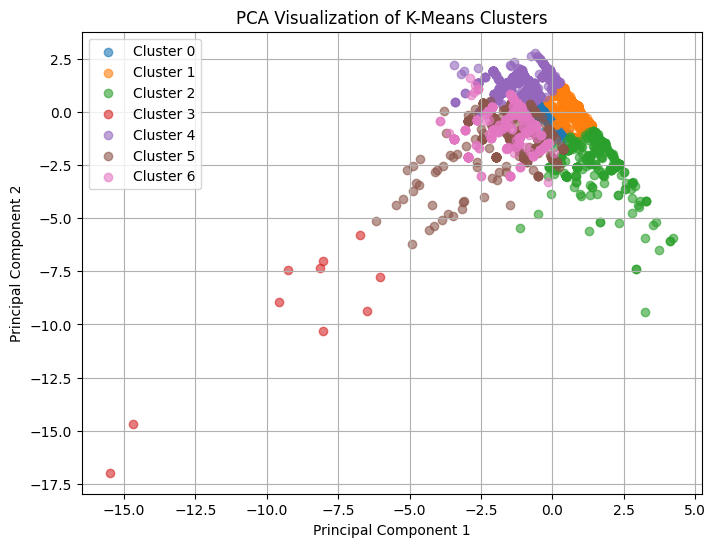

In [ ]:
pdf = pca_plot_df.select("pc1", "pc2", "prediction").sample(0.2).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in sorted(pdf["prediction"].unique()):
    cluster_data = pdf[pdf["prediction"] == cluster]
    plt.scatter(
        cluster_data["pc1"],
        cluster_data["pc2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of K-Means Clusters")
plt.legend()
plt.grid(True)
plt.show()



**Interpretation**

K-Means clustering with k=8 revealed distinct groupings of collective agreements. PCA visualization confirms reasonable cluster separation, with one cluster clearly isolated, indicating agreements with unique characteristics.


**Clear cluster structure**


* Clusters 6 and 5 are compact and well separated


* Indicates that K-Means found meaningful groupings and features used for clustering are informative


**Overlapping clusters** 


* Clusters 1,2, 0 and 4 overlap around (PC1 ≈ -1 to 1)


* This is normal and expected because:


* PCA compresses high-dimensional data into 2D


* Overlap does not mean poor clustering


“Some overlap is observed due to dimensionality reduction and similarity between agreements.”


**Cluster 3 (red points)**

* Cluster far left & bottom (large negative PC1 & PC2)

* This suggests that outlier group

* Possibly agreements with:

   * Very high or very low employee counts

   * Unusual contract lengths


